In [14]:
import torch
import matplotlib.pyplot as plt
# local
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

from datasets.import_dataset import import_dataset
from trainer import Trainer
import clamiter as ci
from utils.plotting import *
from utils.utils import clam_edges_from_feats

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device = {device}')
from datasets.simulations import create_sbm

%load_ext autoreload
%autoreload 2

device = cpu
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Distance Experiments

In [ ]:
plot_distance_experiment(0.01, 'find_d', ds_name='squirrel', range=300)

NameError: name 'plot_distance_experiment' is not defined



/tmp/ipykernel_5049/3843112464.py:24:::  d=0.0005


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-28 21:57:14 starting optimization of ieclam on squirrel on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_iter": 15000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 14999


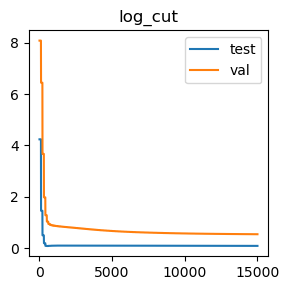

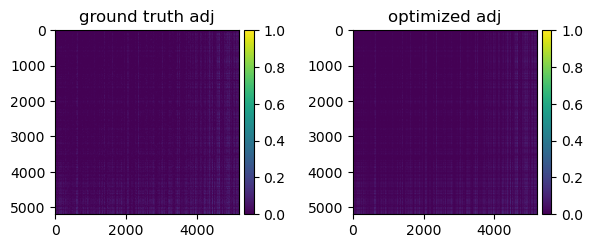



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.08439721927150226
val
key='l2': 0.5386378765106201


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





/tmp/ipykernel_5049/3843112464.py:24:::  d=0.001


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-28 22:47:48 starting optimization of ieclam on squirrel on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_iter": 15000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 14999


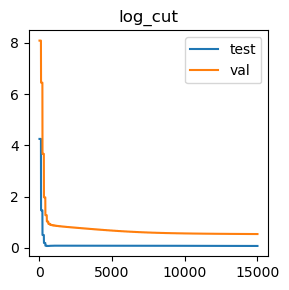

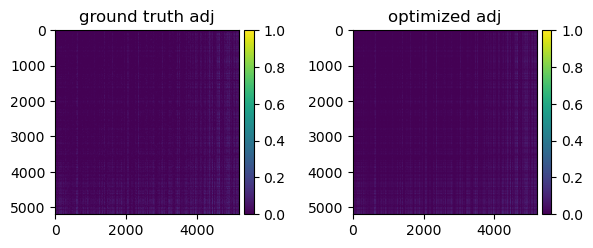



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.07347160075676887
val
key='l2': 0.5381546020507812


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





/tmp/ipykernel_5049/3843112464.py:24:::  d=0.0001


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-28 23:38:49 starting optimization of ieclam on squirrel on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_iter": 15000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 14999


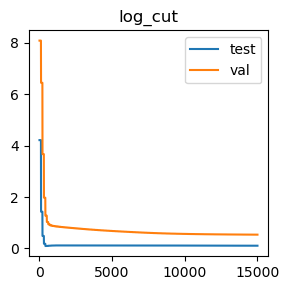

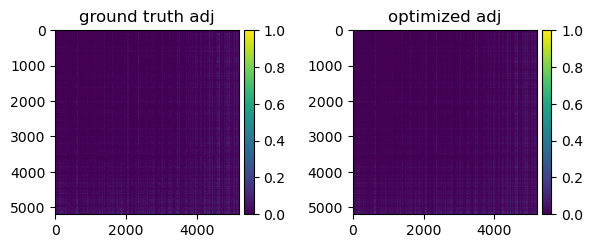



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.1071419707493423
val
key='l2': 0.5368380546569824


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [10]:
'''Experiment: for every dataset we used find the best d and see that the log cut converges.'''

import os
import numpy as np


#
for ds_name in ['squirrel']:
    for model_name in ['ieclam']:
        ds = import_dataset(ds_name)


        # SBM
        config_triplets = [
                            ['feat_opt', 'n_iter', 15000],
                            # ['feat_opt', 'lr', 0.00005],
                            # ['prior_opt', 'n_iter', 1500],
                            # ['prior_opt', 'lr', 0.0000005],
                            # ['back_forth','n_back_forth', 30],
                            # ['back_forth', 'first_func_in_fit', 'feat_opt']
                          ]

        for d in [0.0005, 0.001, 0.0001]:
            printd(f'{d=}')
            trainer = Trainer(
                        model_name=model_name,
                        task='distance',
                        device=device,
                        config_triplets_to_change=config_triplets,
                        dataset=ds.clone()
            )
            # i want to optimize the trainer
            log_likelihoods, test_accs, val_accs = trainer.train(
                d=d,
                plot_every=-1,
                init_feats=True,
                init_type='small_gaus',
                verbose=False,
                acc_every=100,
                verbose_in_funcs=False
            )

            log_likelihoods = np.array(log_likelihoods)/(ds.num_nodes**2)


            dir_path = f'results/distance/find_d/{ds_name}/{model_name}/d_{d}'
            if not os.path.exists(dir_path):
                os.makedirs(dir_path)
            torch.save(test_accs['log_cut'], dir_path + f'/logcuts.pt')
            torch.save(log_likelihoods, dir_path + f'/log_likelihoods.pt')
            torch.save(val_accs['l2'], dir_path + f'/l2s.pt')
            
            del trainer.data
            if trainer.clamiter.prior is not None:
                del trainer.clamiter.prior.model
            




/tmp/ipykernel_5049/4048695586.py:24:::  d=0.0005


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-29 01:43:00 starting optimization of ieclam on photo on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 0.0001,
        "n_iter": 5000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:362:::  fit wrapper fit_feats error in iter_step at iter 7: fufv has negative vals - crossed the potential wall at 0


/home/user/Documents/danny/AAAI_pieclam/experiments/../utils/utils.py:412: RuntimeWarning: divide by zero encountered in log
  inverted_p = np.log(1 - p)
/home/user/anaconda3/envs/piegam/lib/python3.11/site-packages/cutnorm/OptManiMulitBallGBB.py:216: RuntimeWarning: invalid value encountered in matmul
  g = 2 * np.c_[np.matmul(Vs, C.T), np.matmul(Us, C)]




/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': nan
val
key='l2': 10.951155662536621


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





/tmp/ipykernel_5049/4048695586.py:24:::  d=0.001


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-29 01:45:06 starting optimization of ieclam on photo on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 0.0001,
        "n_iter": 5000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:362:::  fit wrapper fit_feats error in iter_step at iter 7: fufv has negative vals - crossed the potential wall at 0


/home/user/Docum

/home/user/anaconda3/envs/piegam/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)




/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': nan
val
key='l2': 13.710931777954102


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





/tmp/ipykernel_5049/4048695586.py:24:::  d=0.0005


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-29 01:49:17 starting optimization of ieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.05,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 0.0001,
        "n_iter": 5000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 4999


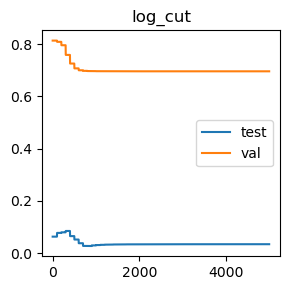

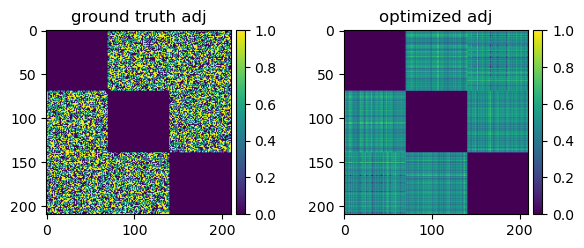

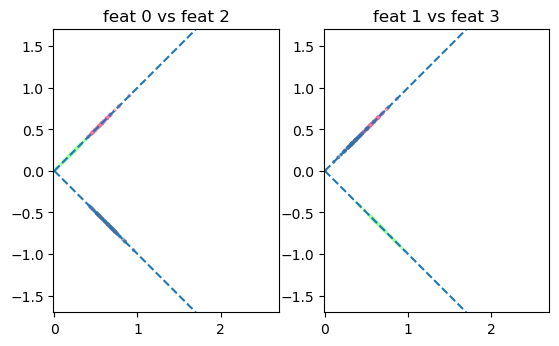



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.03417845764141514
val
key='l2': 0.6961436867713928


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





/tmp/ipykernel_5049/4048695586.py:24:::  d=0.001


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-29 01:49:35 starting optimization of ieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.05,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 0.0001,
        "n_iter": 5000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 4999


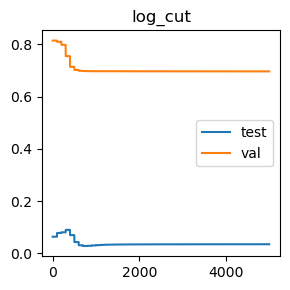

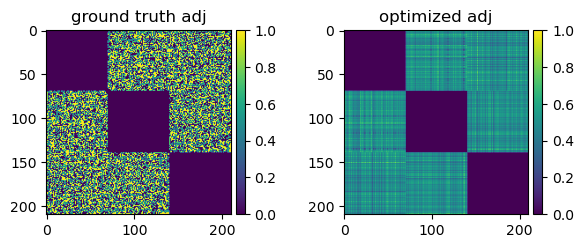

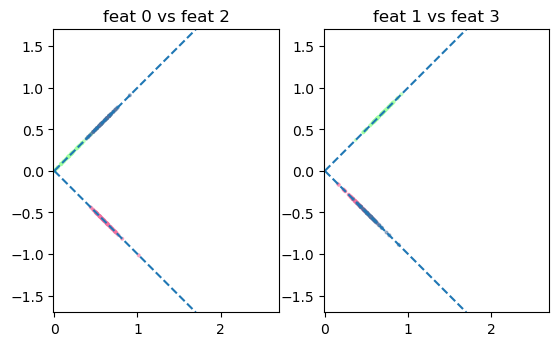



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.0345409914498818
val
key='l2': 0.6962990760803223


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





/tmp/ipykernel_5049/4048695586.py:24:::  d=0.0001


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-29 01:49:53 starting optimization of ieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.05,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 0.0001,
        "n_iter": 5000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 4999


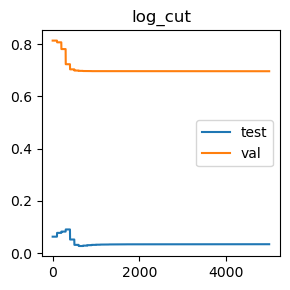

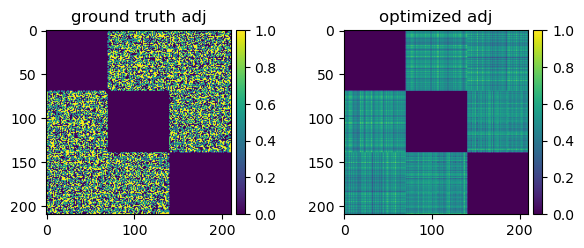

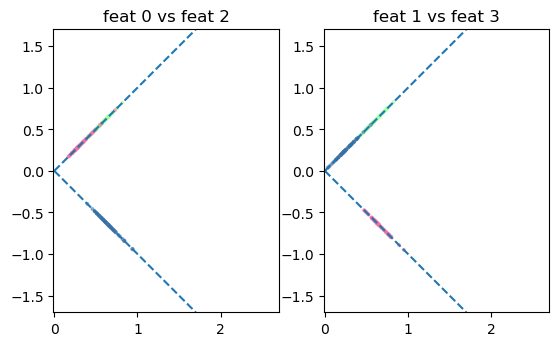



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.03377753088015277
val
key='l2': 0.6962012052536011


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [ ]:
'''Experiment: for every dataset we used find the best d and see that the log cut converges.'''

import os
import numpy as np


#
for ds_name in ['photo', 'sbm3x3HalfDiag']:
    for model_name in ['ieclam']:
        ds = import_dataset(ds_name)


        # SBM
        config_triplets = [
                            ['feat_opt', 'n_iter', 5000],
                            ['feat_opt', 'lr', 0.00005],
                            # ['prior_opt', 'n_iter', 1500],
                            # ['prior_opt', 'lr', 0.0000005],
                            # ['back_forth','n_back_forth', 30],
                            # ['back_forth', 'first_func_in_fit', 'feat_opt']
                          ]

        for d in [0.0005, 0.001, 0.0001]:
            printd(f'{d=}')
            trainer = Trainer(
                        model_name=model_name,
                        task='distance',
                        device=device,
                        config_triplets_to_change=config_triplets,
                        dataset=ds.clone()
            )
            # i want to optimize the trainer
            log_likelihoods, test_accs, val_accs = trainer.train(
                d=d,
                plot_every=-1,
                init_feats=True,
                init_type='small_gaus',
                verbose=False,
                acc_every=100,
                verbose_in_funcs=False
            )

            log_likelihoods = np.array(log_likelihoods)/(ds.num_nodes**2)


            dir_path = f'results/distance/find_d/{ds_name}/{model_name}/d_{d}'
            if not os.path.exists(dir_path):
                os.makedirs(dir_path)
            torch.save(test_accs['log_cut'], dir_path + f'/logcuts.pt')
            torch.save(log_likelihoods, dir_path + f'/log_likelihoods.pt')
            torch.save(val_accs['l2'], dir_path + f'/l2s.pt')
            
            del trainer.data
            if trainer.clamiter.prior is not None:
                del trainer.clamiter.prior.model

In [ ]:
plot_distance_experiment(0.01, 'train_to_overfit', 'squirrel', 'ieclam', 4900)

#? experimental insight: the approximation matrix reaches values of 1 via the log likelihood optimization in which case the log cut is infinity. so the limitation is also via the step size...



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-29 10:37:29 starting optimization of ieclam on squirrel on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 30,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_iter": 45000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../utils/utils.py:412: RuntimeWarning: divide by zero encountered in log
  inverted_p = np.log(1 - p)
/home/user/anaconda3/envs/piegam/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)




/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 44999


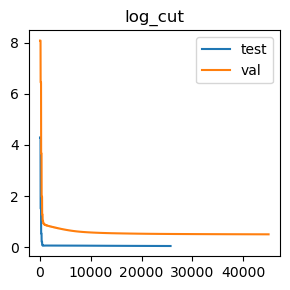

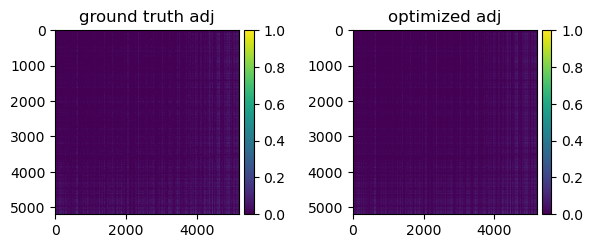



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': nan
val
key='l2': 0.5000901222229004


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [ ]:
'''Experiment: try and get overfitting in the log cut distance. If we train the model for long enough, we expect that the log cut will start increasing because of overfitting so we are training it for a very long time.'''
from datetime import datetime


model_name = 'ieclam'
ds = import_dataset('squirrel')
d = 0.005
n_iter = 45000
config_triplets = [
                    ['feat_opt', 'n_iter', n_iter],
                    # ['feat_opt', 'lr', 0.00005],
                    # ['prior_opt', 'n_iter', 1500],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 30],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]

trainer = Trainer(
            model_name=model_name,
            task='distance',
            device=device,
            config_triplets_to_change=config_triplets,
            dataset=ds.clone()
)
# i want to optimize the trainer
try:
    log_likelihoods, test_accs, val_accs = trainer.train(
        d=d,
        plot_every=-1,
        init_feats=True,
        init_type='small_gaus',
        verbose=False,
        acc_every=100,
        verbose_in_funcs=False
    )

    log_likelihoods = np.array(log_likelihoods)/(ds.num_nodes**2)
except Exception as e:
    raise

finally:
    dir_path = f'results/distance/train_to_overfit/squirrel/ieclam/d_{d}/n_iter_{n_iter}/{datetime.now().strftime("%Y-%m-%d_%H-%M")}'
    
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)

    torch.save(test_accs['log_cut'], dir_path + f'/logcuts')
    torch.save(log_likelihoods, dir_path + f'/log_likelihoods')
    torch.save(val_accs['l2'], dir_path + f'/l2s')

    del trainer.data
    if trainer.clamiter.prior is not None:
        del trainer.clamiter.prior.model

    #todo: print every 1000 iterations
    #todo: find where it gets infinity (and what,,,)


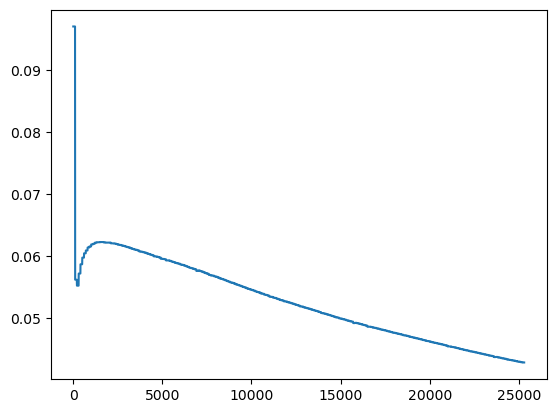

In [19]:
plt.plot(test_accs['log_cut'][400:])

# SBM

# Tripart

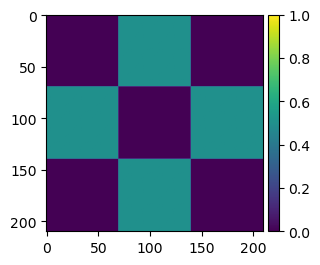

In [5]:
# import sbm and bipartite
ds_tripartite = import_dataset('tripartite')

# plot_adj(ds_sbm_halfcenter.edge_index, ax=axes[0])
# plot_adj(ds_sbm_halfdiag.edge_index, ax=axes[1])

# create sbm
prob_adj_3X3, y = create_sbm_undirected(70, p_comm=[0.0, 0.0, 0.0], p_bipart=[0.5, 0.0, 0.5]) 
plot_adj(prob_adj_3X3)

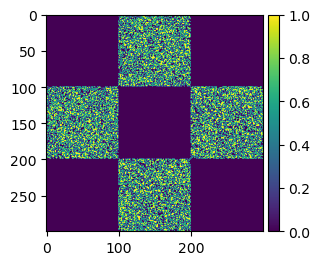

In [6]:
plot_adj(to_dense_adj(ds_tripartite.edge_index)[0])



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:161:::  

Using dataset specific configuration and not global 




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:335:::  

 2025-07-05 22:14:07 starting optimization of ieclam on tripartite on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_iter": 150000,
        "early_stop": 0
    }
}


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:365:::  
staring fit_feats for 150000 iterations


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:393:::  

fit wrapper fit_feats, plotting state at iter 149999


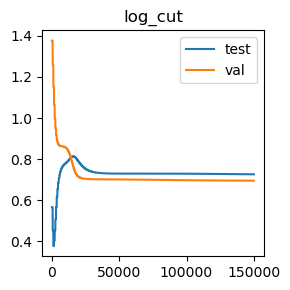

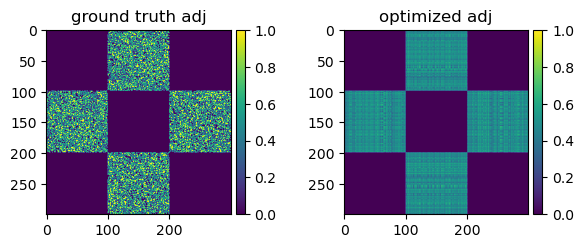

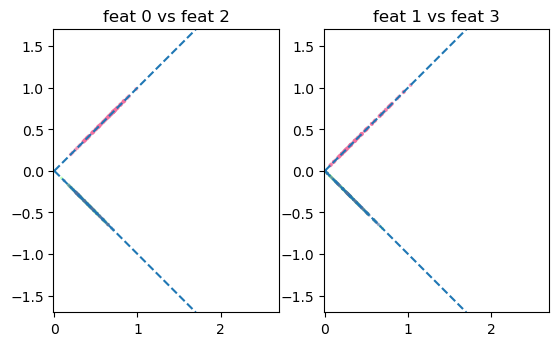

DISTANCE VAL:
latest:
value: {'l2': 0.6950306296348572}
best:
value, iteration: ({'l2': 1.3767329454421997}, {'l2': 0})
TEST accuracy.
Latest:
log_cut: 0.7260674349971821 
Best:
log_cut: 0.8140448528151225 at iteration 15500


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:438:::  



FINISHED train 
 last accuracies:
test
key='log_cut': 0.7260674349971821
val
key='l2': 0.6950306296348572




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:454:::  

train_model_on_params on ieclam tripartite 
took 367.62185502052307 seconds


In [22]:
config_triplets = [
                    ['feat_opt', 'n_iter', 150000],
                    ['clamiter_init', 'dim_feat', 4],
                    # ['feat_opt', 'lr', 0.00003],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 5],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfdiag_ieclam = Trainer(
                model_name='ieclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_tripartite.clone()
                
)

losses_halfdiag_ieclam, logcut_halfdiag_ieclam, l2_halfdiag_ieclam = trainer_halfdiag_ieclam.train(
    d = 0.01,
    plot_every=-1,
    init_feats=True,
    init_type='small_gaus',
    acc_every=500,
    verbose=False,
    verbose_in_funcs=False
)




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:161:::  

Using dataset specific configuration and not global 




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:335:::  

 2025-07-05 22:20:15 starting optimization of bigclam on tripartite on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 10,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_iter": 150000,
        "early_stop": 0
    }
}


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:365:::  
staring fit_feats for 150000 iterations


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:393:::  

fit wrapper fit_feats, plotting state at iter 149999


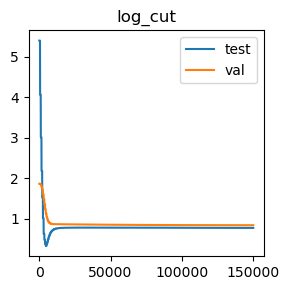

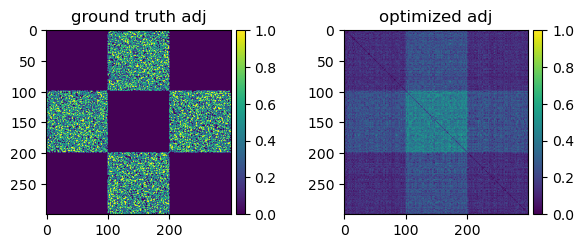

DISTANCE VAL:
latest:
value: {'l2': 0.8427303433418274}
best:
value, iteration: ({'l2': 1.866287350654602}, {'l2': 0})
TEST accuracy.
Latest:
log_cut: 0.7760540827853092 
Best:
log_cut: 5.396261962625211 at iteration 0


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:438:::  



FINISHED train 
 last accuracies:
test
key='log_cut': 0.7760540827853092
val
key='l2': 0.8427303433418274




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:454:::  

train_model_on_params on bigclam tripartite 
took 486.05787897109985 seconds


In [23]:
config_triplets = [
                    ['feat_opt', 'n_iter', 150000],
                    ['clamiter_init', 'dim_feat', 10],
                    # ['feat_opt', 'lr', 0.00003],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 5],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfdiag_bigclam = Trainer(
                model_name='bigclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_tripartite.clone()
                
)

losses_halfdiag_bigclam, logcut_halfdiag_bigclam, l2_halfdiag_bigclam = trainer_halfdiag_bigclam.train(
    d = 0.01,
    plot_every=-1,
    init_feats=True,
    init_type='small_gaus',
    acc_every=500,
    verbose=False,
    verbose_in_funcs=False
)


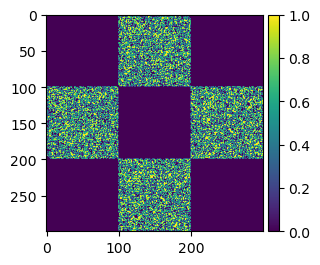

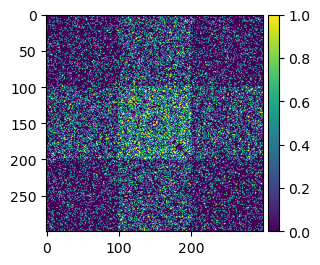

In [24]:
ieclam_adj = to_dense_adj(clam_edges_from_feats(trainer_halfdiag_ieclam.data.x, lorenz=True).edge_index)[0]
bigclam_adj = to_dense_adj(clam_edges_from_feats(trainer_halfdiag_bigclam.data.x, lorenz=False).edge_index)[0]

plot_adj(ieclam_adj)
plot_adj(bigclam_adj)

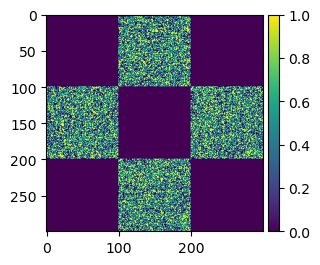

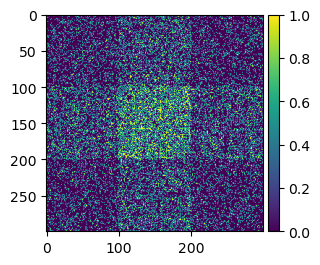

In [21]:
ieclam_adj = to_dense_adj(clam_edges_from_feats(trainer_halfdiag_ieclam.data.x, lorenz=True).edge_index)[0]
bigclam_adj = to_dense_adj(clam_edges_from_feats(trainer_halfdiag_bigclam.data.x, lorenz=False).edge_index)[0]

plot_adj(ieclam_adj)
plot_adj(bigclam_adj)

## HalfDiag

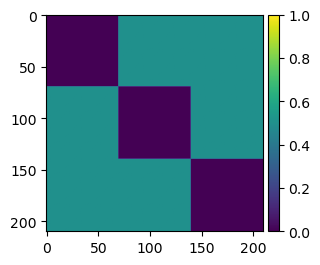

In [2]:
# import sbm and bipartite
ds_sbm_halfdiag = import_dataset('sbm3x3HalfDiag')
ds_sbm_halfcenter = import_dataset('sbm3x3HalfCenter')

# plot_adj(ds_sbm_halfcenter.edge_index, ax=axes[0])
# plot_adj(ds_sbm_halfdiag.edge_index, ax=axes[1])

# create sbm
prob_adj_3X3, y = create_sbm_undirected(70, p_comm=[0.0, 0.0, 0.0], p_bipart=[0.5, 0.5, 0.5]) 
plot_adj(prob_adj_3X3)


### Lorenz Inner

#### IEClam



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-26 19:57:04 starting optimization of ieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.05,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 15000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 14999


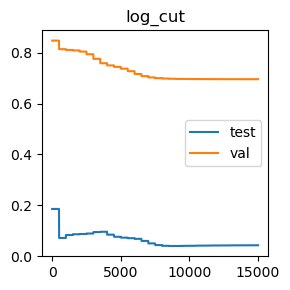

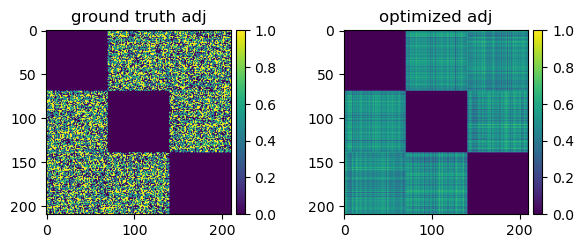

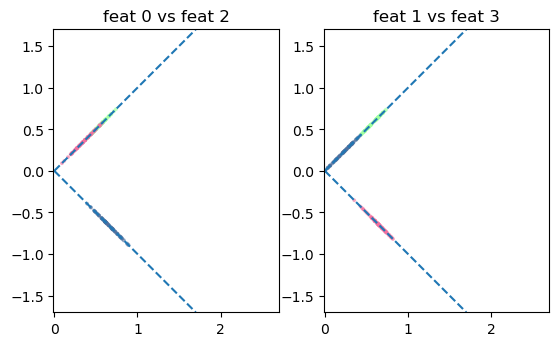



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.04301553354984352
val
key='l2': 0.6955191493034363


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [3]:
config_triplets = [
                    ['feat_opt', 'n_iter', 15000],
                    # ['feat_opt', 'lr', 0.00003],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 5],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfdiag_ieclam = Trainer(
                model_name='ieclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfdiag.clone()
                
)

losses_halfdiag_ieclam, logcut_halfdiag_ieclam, l2_halfdiag_ieclam = trainer_halfdiag_ieclam.train(
    d = 0.01,
    plot_every=-1,
    init_feats=True,
    init_type='small_gaus',
    acc_every=500,
    verbose=False,
    verbose_in_funcs=False
)

# todo: move the contents of train into fit and then do trainer.clamiter.fit() not urgent. add an option for trainer to do cross validation.

#### PieClam



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-26 19:57:20 starting optimization of pieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 6,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 0.0,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 0.0001,
        "n_iter": 2000,
        "early_stop": 0
    },
    "prior_opt": {
        "n_iter": 2000,
        "lr": 1e-05,
        "noise_amp": 0.1,
        "weight_decay": 0.01,
        "early_stop": 0
    },
    "back_forth": {
        "n_back_forth": 5,
        "scheduler_step_size": 100,
        "scheduler_gamma": 0.5,
        "early_stop_fit": 0,
        "first_func_in_fit": "fit_prior"
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:548:::  
in fit,
first_func_in_fit='fit_prior'
second_function_name='fit_feats'



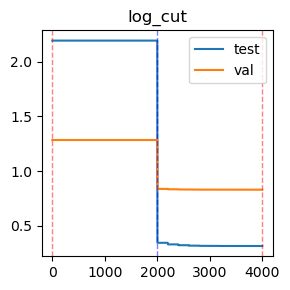

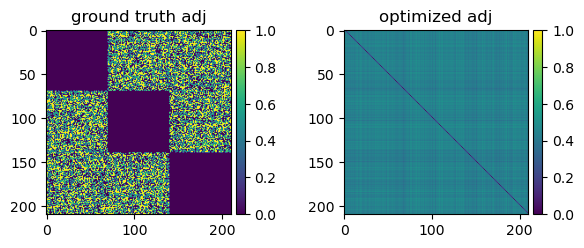

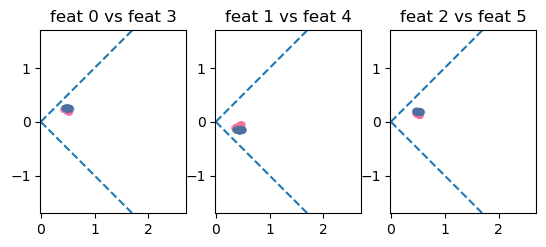



/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:607:::  
back and forth 2/5


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:665:::  
fit, plotting state at iter 2.
dataset: sbm3x3HalfDiag, ,model: pieclam


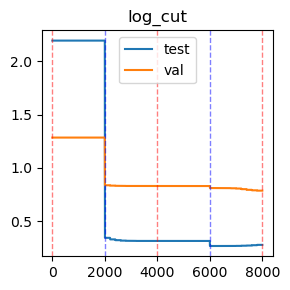

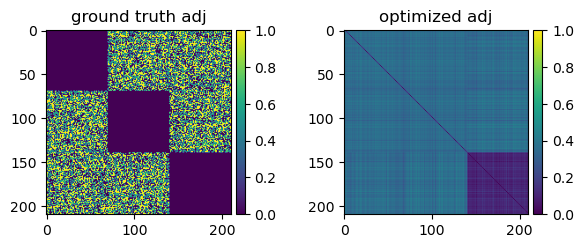

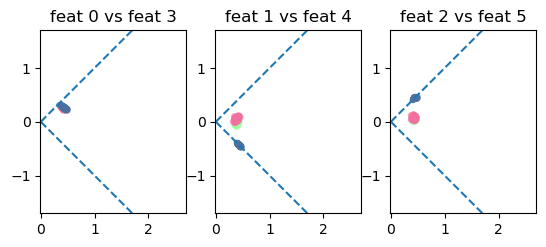



/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:607:::  
back and forth 3/5


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:665:::  
fit, plotting state at iter 3.
dataset: sbm3x3HalfDiag, ,model: pieclam


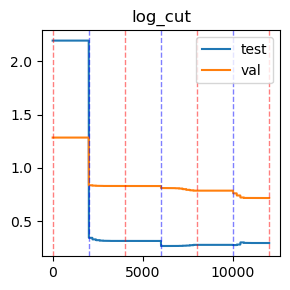

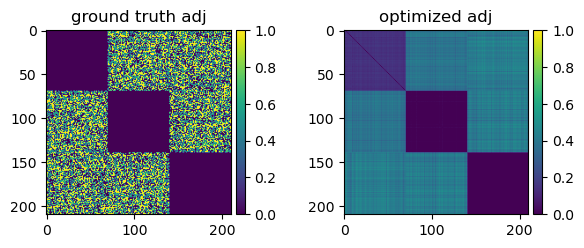

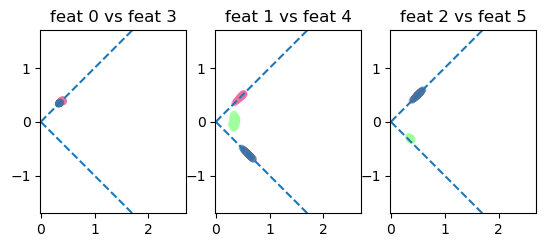



/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:607:::  
back and forth 4/5


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:665:::  
fit, plotting state at iter 4.
dataset: sbm3x3HalfDiag, ,model: pieclam


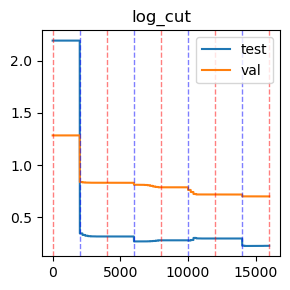

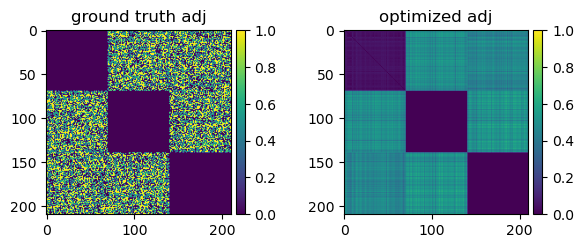

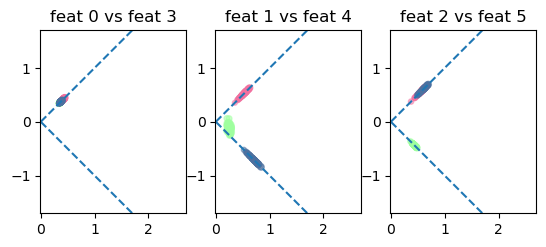



/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:607:::  
back and forth 5/5


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:665:::  
fit, plotting state at iter 5.
dataset: sbm3x3HalfDiag, ,model: pieclam


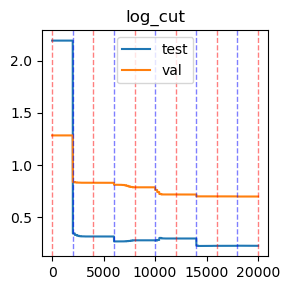

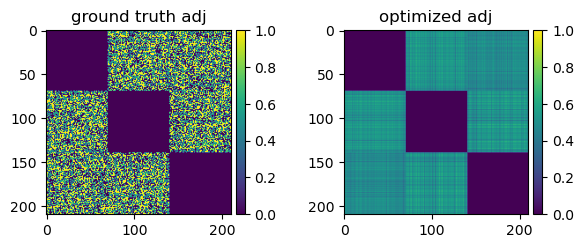

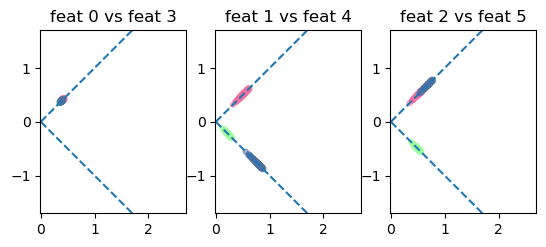



/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:671:::  
fit end, no early stopping


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.22622002032887112
val
key='l2': 0.6986995935440063


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [4]:
config_triplets = [
                    # ['feat_opt', 'n_iter', 200],
                    ['clamiter_init', 'dim_feat', 6],
                    ['feat_opt', 'lr', 0.0001],
                    # ['prior_opt', 'n_iter', 150],
                    ['prior_opt', 'lr', 0.00001],
                    ['back_forth','n_back_forth', 5],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfdiag_pieclam = Trainer(
                model_name='pieclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfdiag
)

losses_halfdiag_pieclam, logcut_halfdiag_pieclam, l2_halfdiag_pieclam = trainer_halfdiag_pieclam.train(
    d = 0.2,
    plot_every=1,
    init_feats=True,
    init_type='small_gaus',
    verbose=False,
    verbose_in_funcs=False,
    node_size_factor=5,
    draw_edges=False
    
    
)
del trainer_halfdiag_pieclam.data   
del trainer_halfdiag_pieclam.clamiter.prior.model

### Inner Prod

#### BIGCLAM



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-26 20:03:38 starting optimization of bigclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 2,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 0.01,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 10000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 9999


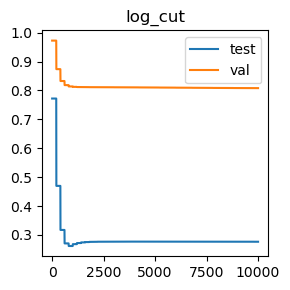

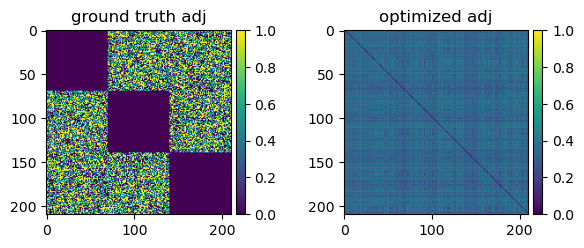

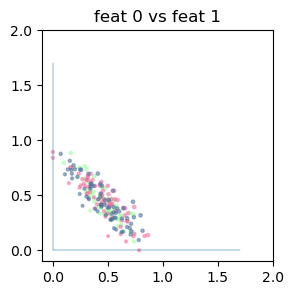



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.27647432099350433
val
key='l2': 0.8080548644065857


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [5]:
config_triplets = [
                    # ['feat_opt', 'n_iter', 2000],
                    # ['feat_opt', 'lr', 0.00003],
                    # ['prior_opt', 'n_iter', 1500],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 50],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfdiag_bigclam= Trainer(
                model_name='bigclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfdiag.clone()
)

losses_halfdiag_bigclam, logcut_halfdiag_bigclam, l2_halfdiag_bigclam = trainer_halfdiag_bigclam.train(
    d = 0.2,
    plot_every=-1,
    init_feats=True,
    init_type='small_gaus',
    verbose=False,
    verbose_in_funcs=False
)

del trainer_halfdiag_bigclam.data

#### PClam



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-26 20:03:47 starting optimization of pclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 6,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 0.1,
        "T": 1,
        "hidden_dim": 128,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 1000,
        "early_stop": 0
    },
    "prior_opt": {
        "n_iter": 2500,
        "lr": 1e-06,
        "noise_amp": 0.1,
        "weight_decay": 0.01,
        "early_stop": 0
    },
    "back_forth": {
        "n_back_forth": 1,
        "scheduler_step_size": 300,
        "scheduler_gamma": 0.1,
        "early_stop_fit": 0,
        "first_func_in_fit": "fit_prior"
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:548:::  
in fit,
first_func_in_fit='fit_prior'
second_function_name='fit_feats'


/

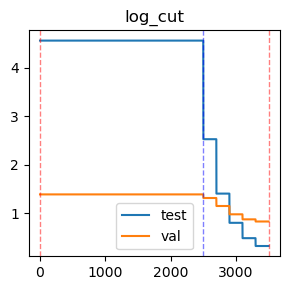

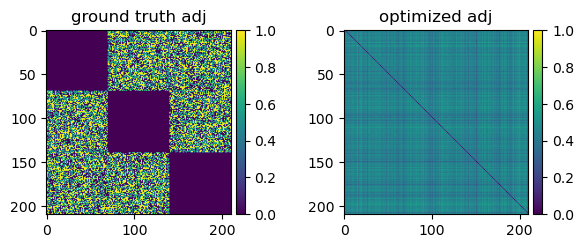

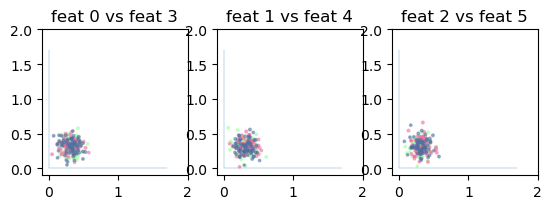



/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:671:::  
fit end, no early stopping


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.3304328261201937
val
key='l2': 0.8343179225921631


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [6]:
# SBM
config_triplets = [
                    ['clamiter_init', 'dim_feat', 6],
                    # ['feat_opt', 'n_iter', 2000],
                    # ['feat_opt', 'lr', 0.00003],
                    # ['prior_opt', 'n_iter', 1500],
                    # ['prior_opt', 'lr', 0.0000005],
                    ['back_forth','n_back_forth', 1],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfdiag_pclam = Trainer(
                model_name='pclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfdiag.clone()
)
# i want to optimize the trainer
losses_halfdiag_pclam, logcut_halfdiag_pclam, l2_halfdiag_pclam = trainer_halfdiag_pclam.train(
    d = 0.2,
    plot_every=1,
    init_feats=True,
    init_type='small_gaus',
    verbose=False,
    verbose_in_funcs=False
)
del trainer_halfdiag_pclam.data
del trainer_halfdiag_pclam.clamiter.prior.model

### Lorenz Inner

#### IEClam



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-26 20:04:48 starting optimization of ieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.05,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 10000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 9999


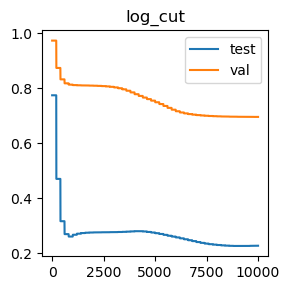

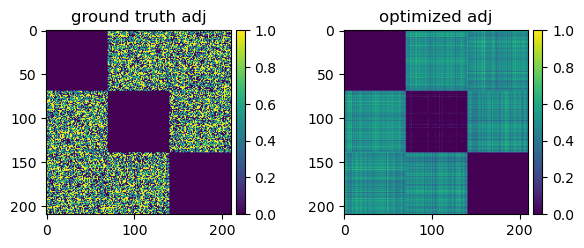

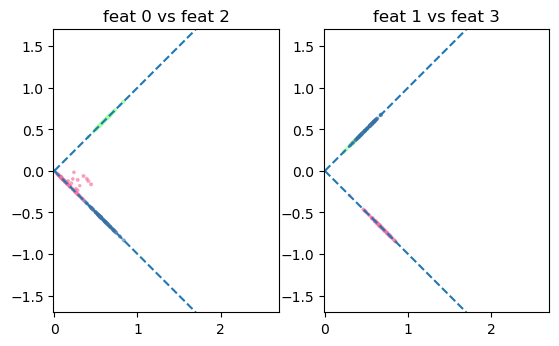



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.2281311587181976
val
key='l2': 0.6964709758758545


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [7]:
config_triplets = [
                    # ['feat_opt', 'n_iter', 2000],
                    # ['feat_opt', 'lr', 0.00003],
                    # ['prior_opt', 'n_iter', 1500],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 50],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfdiag_ieclam = Trainer(
                model_name='ieclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfdiag.clone()
)

losses_halfdiag_ieclam, logcut_halfdiag_ieclam, l2_halfdiag_ieclam = trainer_halfdiag_ieclam.train(
    d = 0.2,
    plot_every=-1,
    init_feats=True,
    init_type='small_gaus',
    verbose=False,
    verbose_in_funcs=False
)

del trainer_halfdiag_ieclam.data


#### PieClam



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-26 20:05:04 starting optimization of pieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 0.0,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 0.0001,
        "n_iter": 2000,
        "early_stop": 0
    },
    "prior_opt": {
        "n_iter": 2000,
        "lr": 1e-05,
        "noise_amp": 0.1,
        "weight_decay": 0.01,
        "early_stop": 0
    },
    "back_forth": {
        "n_back_forth": 5,
        "scheduler_step_size": 100,
        "scheduler_gamma": 0.5,
        "early_stop_fit": 0,
        "first_func_in_fit": "fit_prior"
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:548:::  
in fit,
first_func_in_fit='fit_prior'
second_function_name='fit_feats'



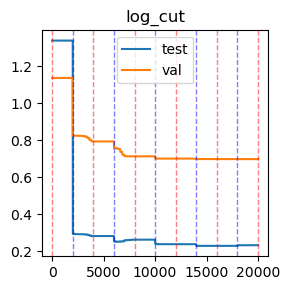

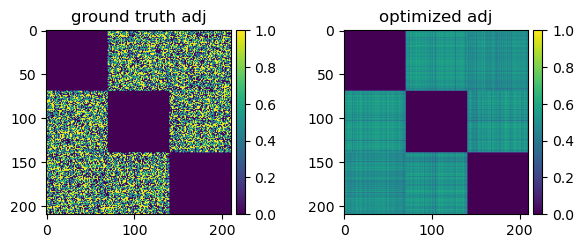

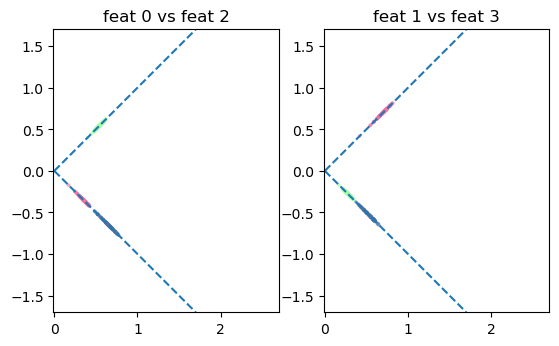



/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:671:::  
fit end, no early stopping


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.23193893267721888
val
key='l2': 0.698152482509613


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [8]:
config_triplets = [
                    # ['feat_opt', 'n_iter', 2000],
                    # ['feat_opt', 'lr', 0.00003],
                    # ['prior_opt', 'n_iter', 1500],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 50],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfdiag_pieclam = Trainer(
                model_name='pieclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfdiag.clone()
)

losses_halfdiag_pieclam, logcut_halfdiag_pieclam, l2_halfdiag_pieclam = trainer_halfdiag_pieclam.train(
    d = 0.2,
    plot_every=-1,
    init_feats=True,
    init_type='small_gaus',
    verbose=False,
    verbose_in_funcs=False
)

del trainer_halfdiag_pieclam.data
del trainer_halfdiag_pieclam.clamiter.prior.model

## HalfCenter

### Lorenz Inner

#### IEClam

In [ ]:
config_triplets = [
                    # ['feat_opt', 'n_iter', 2000],
                    # ['feat_opt', 'lr', 0.00003],
                    # ['prior_opt', 'n_iter', 1500],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 50],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfcenter_ieclam = Trainer(
                model_name='ieclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfcenter.clone()
)

losses_halfcenter_ieclam, logcut_halfcenter_ieclam, l2_halfcenter_ieclam = trainer_halfcenter_ieclam.train(
    d = 0.2,
    plot_every=-1,
    init_feats=True,
    init_type='small_gaus',
    verbose=False,
    verbose_in_funcs=False
)
del trainer_halfcenter_ieclam.data

#### PieClam

In [ ]:
config_triplets = [
                    # ['feat_opt', 'n_iter', 200],
                    ['feat_opt', 'lr', 0.0001],
                    # ['prior_opt', 'n_iter', 150],
                    ['prior_opt', 'lr', 0.00001],
                    ['back_forth','n_back_forth', 5],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfcenter_pieclam = Trainer(
                model_name='pieclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfcenter.clone()
)

losses_halfcenter_pieclam, logcut_halfcenter_pieclam, l2_halfcenter_pieclam = trainer_halfcenter_pieclam.train(
    d = 0.2,
    plot_every=-1,
    init_feats=True,
    init_type='small_gaus',
    verbose=False,
    verbose_in_funcs=False
)
del trainer_halfcenter_pieclam.data
del trainer_halfcenter_pieclam.clamiter.prior.model

### Inner Prod

#### BIGCLAM

In [ ]:
config_triplets = [
                    # ['feat_opt', 'n_iter', 2000],
                    # ['feat_opt', 'lr', 0.00003],
                    # ['prior_opt', 'n_iter', 1500],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 50],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfcenter_bigclam= Trainer(
                model_name='bigclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfcenter.clone()
)

losses_halfcenter_bigclam, logcut_halfcenter_bigclam, l2_halfcenter_bigclam = trainer_halfcenter_bigclam.train(
    d = 0.2,
    plot_every=-1,
    init_feats=True,
    init_type='small_gaus',
    verbose=False,
    verbose_in_funcs=False
)

del trainer_halfcenter_bigclam.data
del trainer_halfcenter_bigclam.clamiter.prior.model

#### PClam

In [ ]:
# SBM
config_triplets = [
                    ['feat_opt', 'n_iter', 2000],
                    ['feat_opt', 'lr', 0.00005],
                    ['prior_opt', 'n_iter', 1500],
                    ['prior_opt', 'lr', 0.0000005],
                    ['back_forth','n_back_forth', 30],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]


trainer_halfcenter_pclam = Trainer(
                model_name='pclam',
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds_sbm_halfcenter.clone()
)
# i want to optimize the trainer
losses_halfcenter_pclam, logcut_halfcenter_pclam, l2_halfcenter_pclam = trainer_halfcenter_pclam.train(
    d = 0.2,
    plot_every=5,
    init_feats=True,
    init_type='small_gaus',
    verbose=False,
    verbose_in_funcs=False
)

del trainer_halfcenter_pclam.data
del trainer_halfcenter_pclam.clamiter.prior.model

# LogCut Convergence

## Find LL and LC Curve for Different d

In [ ]:
import os
import torch
import matplotlib.pyplot as plt

from utils.plotting import plot_distance_experiment



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-27 01:46:51 starting optimization of ieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.05,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 15000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 14999


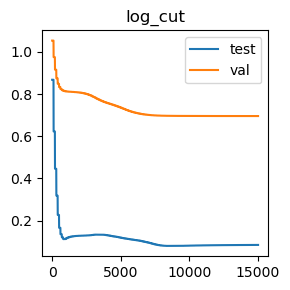

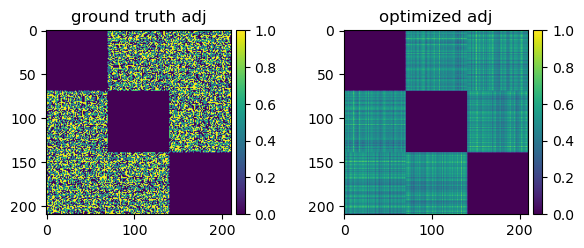

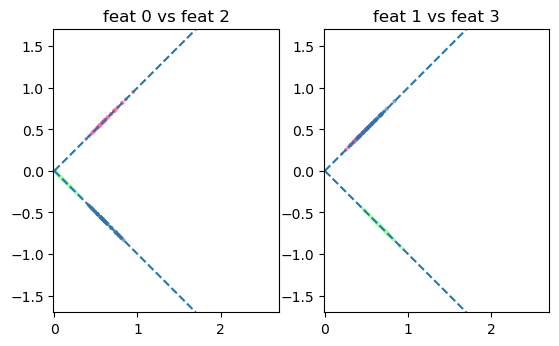



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.08482095937974832
val
key='l2': 0.6960191130638123


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-27 01:47:29 starting optimization of ieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.05,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 15000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 14999


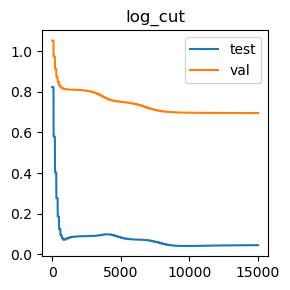

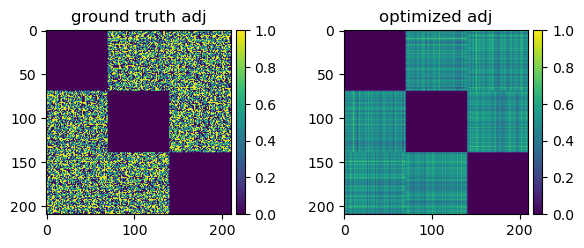

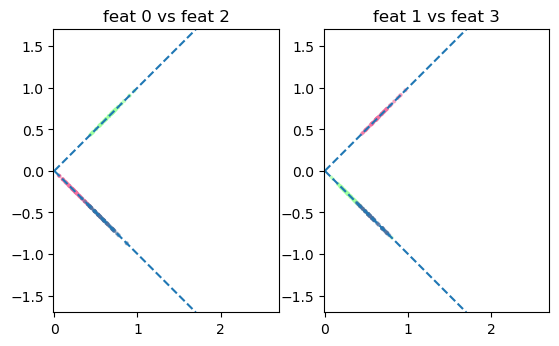



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.04456087380878036
val
key='l2': 0.6959033608436584


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:318:::  
 2025-01-27 01:48:04 starting optimization of ieclam on sbm3x3HalfDiag on device cuda

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.05,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 15000,
        "early_stop": 0
    }
}


/home/user/Documents/danny/AAAI_pieclam/experiments/../clamiter.py:376:::  
fit wrapper fit_feats, plotting state at iter 14999


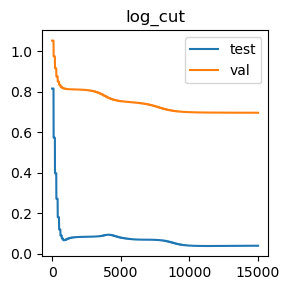

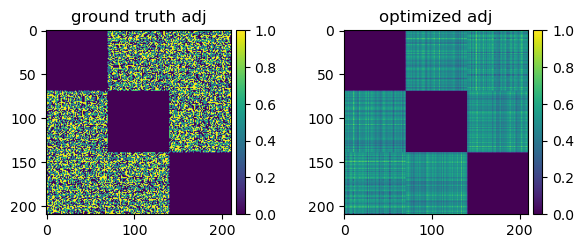

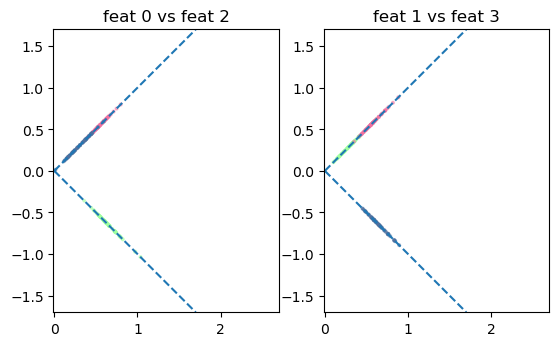



/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:420:::  


FINISHED train 
 last accuracies:
test
key='log_cut': 0.039450490200063144
val
key='l2': 0.6961026191711426


/home/user/Documents/danny/AAAI_pieclam/experiments/../trainer.py:434:::  





In [9]:
'''Experiment: Find the best d. since the log cut distance is defined by the minimal d, we look to see which d gives the minimal value. In any case, the true log cut distance will always be smaller than what is calculated.'''

import os


model_name='ieclam'
ds_name = 'sbm3x3HalfDiag'



ds = import_dataset(ds_name)


# SBM
config_triplets = [
                    ['feat_opt', 'n_iter', 15000],
                    # ['feat_opt', 'lr', 0.00005],
                    # ['prior_opt', 'n_iter', 1500],
                    # ['prior_opt', 'lr', 0.0000005],
                    # ['back_forth','n_back_forth', 30],
                    # ['back_forth', 'first_func_in_fit', 'feat_opt']
                ]

for d in [0.05, 0.01, 0.005]:
    trainer = Trainer(
                model_name=model_name,
                task='distance',
                device=device,
                config_triplets_to_change=config_triplets,
                dataset=ds.clone()
    )
    # i want to optimize the trainer
    log_likelihoods, test_accs, val_accs = trainer.train(
        d=d,
        plot_every=-1,
        init_feats=True,
        init_type='small_gaus',
        verbose=False,
        acc_every=100,
        verbose_in_funcs=False
    )

    log_likelihoods = np.array(log_likelihoods)/(ds.num_nodes**2)


    dir_path = f'results/distance/find_d/{ds_name}/ieclam/d_{d}'
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)
    torch.save(test_accs['log_cut'], dir_path + f'/logcuts')
    torch.save(log_likelihoods, dir_path + f'/log_likelihoods')
    torch.save(val_accs['l2'], dir_path + f'/l2s')
    
    del trainer.data
    if trainer.clamiter.prior is not None:
        del trainer.clamiter.prior.model
    

#todo: make one run for 50000 iteration and see if the log cut converges.

